# 有猫 / 无猫 图像分类 - MobileNetV2 + PyTorch

## 实验目标：
1. 加载我们自己采集的有猫 / 无猫图片数据集；
2. 使用预训练的 MobileNetV2 做迁移学习；
3. 训练一个二分类模型（有猫 / 无猫）；
4. 评估模型效果（准确率 + 混淆矩阵）；
5. 保存模型，为后续在网关/系统中集成做准备。


## Step 1：环境准备 & 挂载 Drive

In [3]:
# Step 1.1: 挂载 Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Step 1.2: 导入基础库
import os
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


device(type='cuda')

In [4]:
# Step 1.3: 设置数据根目录（学生要改成自己的路径）
data_dir = "/content/drive/MyDrive/catbox/dataset"  # TODO: 替换成你自己的路径

print("Data root:", data_dir)
print("子目录:", os.listdir(data_dir))


Data root: /content/drive/MyDrive/catbox/dataset
子目录: ['train']


## Step 2. 定义 transforms(图片处理) + DataLoader



In [5]:
import torch
import torchvision
from torchvision import transforms
from torch.utils.data import DataLoader, random_split
from torchvision.datasets import ImageFolder
import os

# TODO: 设定 image_size 和 batch_size
image_size = 224
batch_size = 32

# TODO: 定义 train_transforms 和 val_transforms
#  - Resize 到 (image_size, image_size)
#  - train 里加一点 RandomHorizontalFlip / ColorJitter
#  - ToTensor + Normalize(使用 ImageNet 均值方差)
train_transforms = transforms.Compose([
    transforms.Resize((image_size, image_size)),
    transforms.RandomHorizontalFlip(0.5),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

val_transforms = transforms.Compose([
    transforms.Resize((image_size, image_size)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])


# 先读取所有数据
d = os.path.join(data_dir, 'train')
print("子目录:", os.listdir(d))
full_dataset = ImageFolder(root=os.path.join(data_dir, 'train'), transform=train_transforms)

# 切分数据集为训练集(70%)和测试集(30%)
train_size = int(0.7 * len(full_dataset))
test_size = len(full_dataset) - train_size
train_dataset, test_dataset = random_split(full_dataset, [train_size, test_size])

# 重新定义 val_dataset 为 test_dataset
val_dataset = test_dataset

# TODO: 用 DataLoader 封装 train_loader 和 val_loader
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=4)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=4)

# TODO: 打印 class_names（train_dataset.classes）以及各自的样本数量
class_names = full_dataset.classes
class_counts = {class_names[i]: 0 for i in range(len(class_names))}

# 统计每个类别的样本数量
for _, label in full_dataset.samples:
    class_counts[class_names[label]] += 1

print("Class names and their sample counts:")
for class_name, count in class_counts.items():
    print(f"  {class_name}: {count}")


子目录: ['no-cat', 'cat']
Class names and their sample counts:
  cat: 146
  no-cat: 218


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


In [6]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Step 3：可视化一个 batch

目标：从 train_loader 里取一批图片，画出来，看一眼数据质量。


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


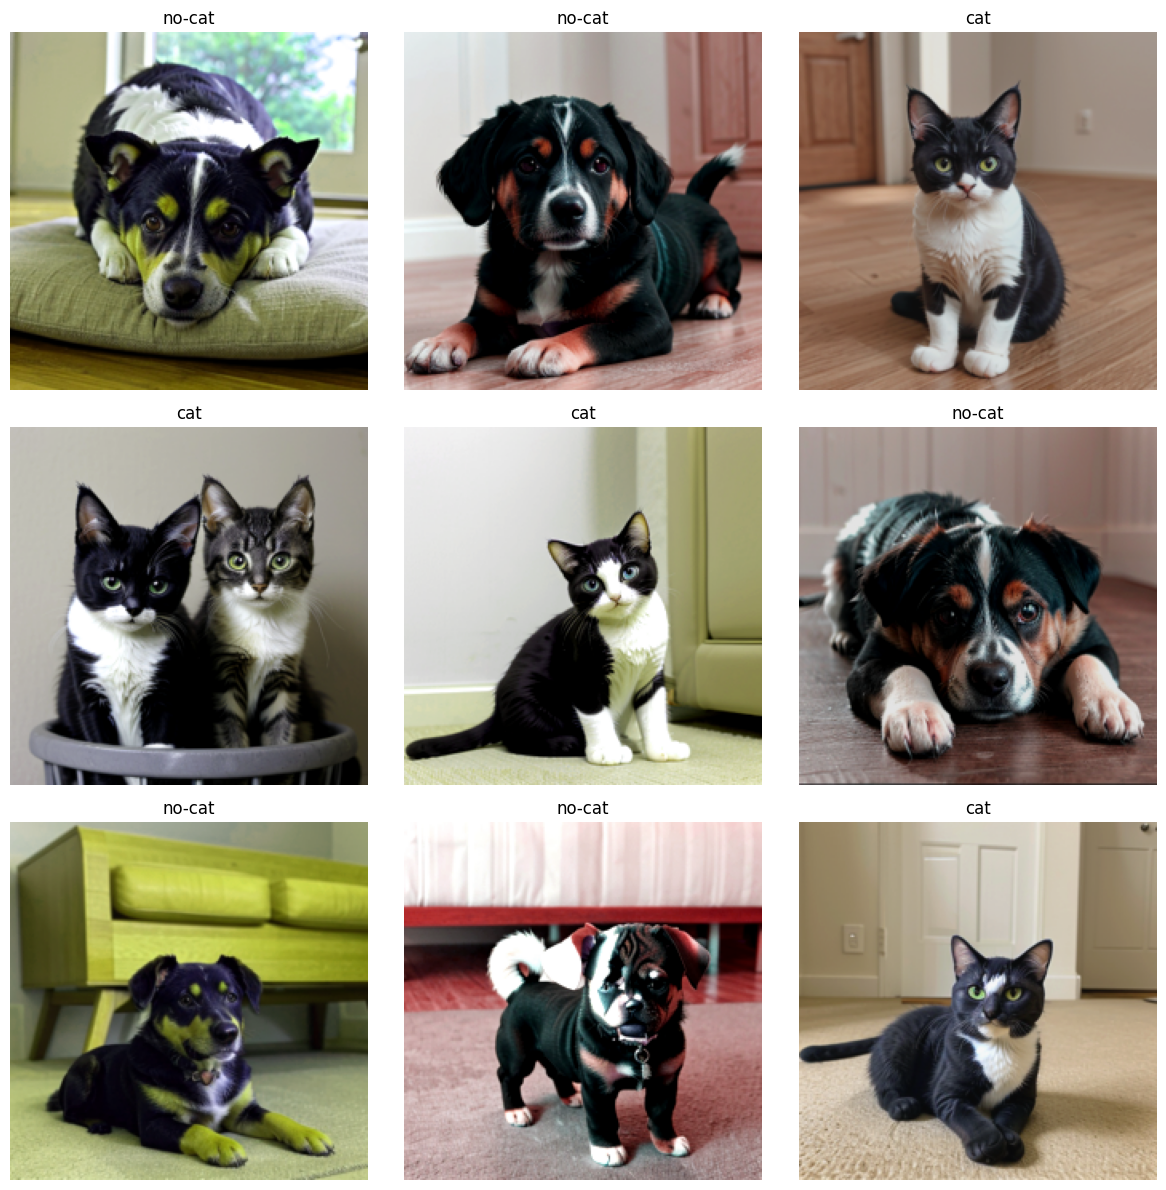

In [7]:
# TODO: 从 train_loader 里取出一个 batch：inputs, labels = next(iter(train_loader))
inputs, labels = next(iter(train_loader))

# TODO: 写一个 imshow(tensor, title) 函数：
#  - 把 tensor 从 (C,H,W) 转成 (H,W,C)
#  - 反归一化回 [0,1] 区间
#  - 用 plt.imshow 显示，并在 title 上写 class_names[label]
def imshow(tensor, title):
    # 把 tensor 从 (C,H,W) 转成 (H,W,C)
    img = tensor.permute(1, 2, 0)

    # 反归一化回 [0,1] 区间
    mean = torch.tensor([0.485, 0.456, 0.406])
    std = torch.tensor([0.229, 0.224, 0.225])
    img = img * std + mean

    # 限制像素值在 [0,1] 区间
    img = torch.clamp(img, 0, 1)

    # 显示图片
    plt.imshow(img.numpy())
    plt.title(title)
    plt.axis('off')

# TODO: 用 plt.figure + for 循环画 3x3 或 4x4 的网格图片
import matplotlib.pyplot as plt

# 创建 3x3 的网格图片
fig = plt.figure(figsize=(12, 12))
num_images = min(9, len(inputs))  # 最多显示9张图片

for i in range(num_images):
    # 创建子图
    ax = fig.add_subplot(3, 3, i + 1)

    # 获取当前图片和标签
    img = inputs[i]
    label = labels[i]

    # 显示图片
    imshow(img, class_names[label])

    # 设置标题
    ax.set_title(class_names[label])

plt.tight_layout()
plt.show()


## Step 4：加载预训练 MobileNetV2 并替换分类头

目标：使用预训练 MobileNetV2，当作特征提取器，仅训练最后一层做 2 类输出。

---

## MobileNetV2 是什么？

* MobileNetV2 是一种**轻量级卷积神经网络**，专门为手机、树莓派这类**算力有限的设备**设计。
* 它的作用和其他 CNN 一样：**输入一张图片 → 输出属于每个类别的概率**（比如“有猫 / 无猫”）。
* 和那些很大的网络（比如 ResNet）相比，MobileNetV2 的特点是：**参数更少、计算更快、占用内存更小**，但准确率仍然不错。

---

## 它的两个小技巧

1. **深度可分离卷积（Depthwise Separable Conv）**

   * 把“普通卷积”拆成两步来做：
     1）先在**每个通道内部**做 3×3 卷积（只看空间，不混通道）；
     2）再用 1×1 卷积在**通道之间**做线性组合。
   * 好处：**计算量大幅减少**，速度更快。

2. **反残差块（Inverted Residual Block）**

   * 一个 block 大概是这样的结构：

     > **窄 → 宽 → 窄 + 残差连接**
   * 具体步骤：
     1）用 1×1 卷积把通道数“拉宽”（expand）；
     2）在宽通道上做 3×3 深度卷积；
     3）再用 1×1 卷积把通道数“压回去”（bottleneck，线性层）；
     4）如果输入输出形状一样，就把**输入加回输出**（shortcut）。
   * 好处：在保持信息的同时，网络整体仍然比较“瘦”和高效。

---

## 简化结构示意图

### 整个网络长什么样？

```text
输入图片 (例如 160x160 RGB)
       │
       ▼
   头部普通卷积
       │
       ▼
 多个 MobileNetV2 小积木
 (反残差 + 深度可分离卷积)
       │
       ▼
  1x1 卷积 + 全局平均池化
       │
       ▼
   全连接层 → 输出类别
         （有猫 / 无猫）
```

### 一个 “MobileNetV2 小积木” 的样子（反残差块）

```text
      输入 (通道较少)
         │
         ▼
   1x1 卷积（扩展通道）
   + ReLU
         │
         ▼
  3x3 深度卷积（每个通道自己卷）
   + ReLU
         │
         ▼
   1x1 卷积（压回少通道）
   （线性，不加 ReLU）
         │
   如果形状一样，就和输入相加
         ▼
      输出 (通道较少)
```

---

## 为什么我们选择 MobileNetV2 做“有猫 / 无猫”？

* **模型小、速度快**：适合未来放在边缘设备（树莓派 / 网关）上跑推理。
* **有现成预训练权重**：可以直接在 ImageNet 预训练的基础上，做“有猫 / 无猫”的迁移学习。
* 对你来说：**更关注数据和训练流程本身**，不需要自己从零写一个很大的网络结构。

In [8]:
# TODO: 从 torchvision.models 导入 mobilenet_v2
from torchvision.models import mobilenet_v2

# TODO: 加载预训练的 MobileNetV2 模型（pretrained=True 或 weights=...）
model = mobilenet_v2(pretrained=True)

# TODO: 冻结 model.features 里的参数 (param.requires_grad = False)
for param in model.features.parameters():
    param.requires_grad = False

# TODO: 打印原始 model.classifier 结构
print("原始 model.classifier 结构:")
print(model.classifier)

# TODO: 取出 num_features = model.classifier[1].in_features
num_features = model.classifier[1].in_features

# TODO: 把 model.classifier[1] 改成 nn.Linear(num_features, 2)
import torch.nn as nn
model.classifier = nn.Sequential(
    nn.Dropout(0.2),
    nn.Linear(num_features, 2)  # 假设有2个类别（猫和非猫）
)

# TODO: 把模型放到 device 上
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

# TODO: 定义 criterion = CrossEntropyLoss()
# TODO: 定义 optimizer = Adam(只传入 model.classifier 参数, lr=1e-3)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.classifier.parameters(), lr=1e-3)


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=MobileNet_V2_Weights.IMAGENET1K_V1`. You can also use `weights=MobileNet_V2_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/mobilenet_v2-b0353104.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-b0353104.pth


100%|██████████| 13.6M/13.6M [00:00<00:00, 91.4MB/s]


原始 model.classifier 结构:
Sequential(
  (0): Dropout(p=0.2, inplace=False)
  (1): Linear(in_features=1280, out_features=1000, bias=True)
)


## Step 5：训练 & 验证循环

In [9]:
# TODO: 定义 train_one_epoch(model, dataloader, optimizer, criterion, device)
#  - model.train()
#  - 循环 dataloader：
#     执行训练循环
#  - 返回 epoch_loss, epoch_acc
def train_one_epoch(model, dataloader, optimizer, criterion, device):
    model.train()
    running_loss = 0.0
    running_corrects = 0
    total = 0

    for inputs, labels in dataloader:
        inputs = inputs.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        _, preds = torch.max(outputs, 1)

        running_loss += loss.item() * inputs.size(0)
        running_corrects += torch.sum(preds == labels.data)
        total += labels.size(0)

    epoch_loss = running_loss / total
    epoch_acc = running_corrects.double() / total

    return epoch_loss, epoch_acc

# TODO: 定义 eval_one_epoch(model, dataloader, criterion, device)
#  - model.eval()
#  - torch.no_grad():
#    * 输出、loss、preds
#    * 统计 running_loss, running_corrects, total
#  - 返回 epoch_loss, epoch_acc
def eval_one_epoch(model, dataloader, criterion, device):
    model.eval()
    running_loss = 0.0
    running_corrects = 0
    total = 0

    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs = inputs.to(device)
            labels = labels.to(device)

            outputs = model(inputs)
            loss = criterion(outputs, labels)
            _, preds = torch.max(outputs, 1)

            running_loss += loss.item() * inputs.size(0)
            running_corrects += torch.sum(preds == labels.data)
            total += labels.size(0)

    epoch_loss = running_loss / total
    epoch_acc = running_corrects.double() / total

    return epoch_loss, epoch_acc


In [ ]:
# TODO: 设定 num_epochs，比如 5
num_epochs = 50

# TODO: 建一个 history 字典，记录 train_loss, train_acc, val_loss, val_acc
history = {
    'train_loss': [],
    'train_acc': [],
    'val_loss': [],
    'val_acc': []
}

# TODO: for epoch in range(num_epochs):
#   - 调用 train_one_epoch(...)
#   - 调用 eval_one_epoch(...)
#   - 把结果写入 history
#   - print 每个 epoch 的 loss/acc
for epoch in range(num_epochs):
    train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion, device)
    val_loss, val_acc = eval_one_epoch(model, val_loader, criterion, device)

    # 把结果写入 history
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc.item())
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc.item())

    # print 每个 epoch 的 loss/acc
    print(f'Epoch {epoch+1}/{num_epochs}:')
    print(f'  Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}')
    print(f'  Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}')
    print('-' * 50)


Epoch 1/50:
  Train Loss: 0.4360, Train Acc: 0.8228
  Val Loss: 0.1627, Val Acc: 0.9909
--------------------------------------------------
Epoch 2/50:
  Train Loss: 0.1699, Train Acc: 0.9449
  Val Loss: 0.0647, Val Acc: 1.0000
--------------------------------------------------
Epoch 3/50:
  Train Loss: 0.1106, Train Acc: 0.9764
  Val Loss: 0.0432, Val Acc: 0.9909
--------------------------------------------------
Epoch 4/50:
  Train Loss: 0.0440, Train Acc: 0.9921
  Val Loss: 0.0362, Val Acc: 1.0000
--------------------------------------------------
Epoch 5/50:
  Train Loss: 0.0475, Train Acc: 0.9843
  Val Loss: 0.0218, Val Acc: 1.0000
--------------------------------------------------
Epoch 6/50:
  Train Loss: 0.0358, Train Acc: 1.0000
  Val Loss: 0.0237, Val Acc: 1.0000
--------------------------------------------------
Epoch 7/50:
  Train Loss: 0.0433, Train Acc: 0.9921
  Val Loss: 0.0216, Val Acc: 1.0000
--------------------------------------------------
Epoch 8/50:
  Train Loss: 0

## Step 6：评估 & 保存模型

目标：
- 计算混淆矩阵和分类报告，看看模型错在什么地方；
- 将训练好的模型权重保存到 Google Drive。


**评估当前模型表现**

In [ ]:
# TODO: 使用 sklearn.metrics 里的 confusion_matrix, classification_report

# TODO: 写一个 get_all_preds(model, dataloader, device)：
#  - model.eval()
#  - torch.no_grad() 下遍历 dataloader，收集所有 labels 和 preds

# TODO: 得到 y_true, y_pred
# TODO: 打印 confusion_matrix(y_true, y_pred)
# TODO: 打印 classification_report(y_true, y_pred, target_names=class_names)
# 获取所有预测结果

**保存模型**

In [ ]:
# TODO: 设定保存路径 save_path 到你自己的 Drive 目录

# TODO: os.makedirs(os.path.dirname(save_path), exist_ok=True)

# TODO: torch.save(model.state_dict(), save_path)

# TODO: print 一下 "Model saved to: ..." 确认保存成功

save_path = "/content/drive/MyDrive/catbox/models/mobilenet_v2_final.pth"
os.makedirs(os.path.dirname(save_path), exist_ok=True)
torch.save(model.state_dict(), save_path)
print("Model saved to:", save_path)
